# Finding a Competent Subset for Visualization, Simulation, or 3D Printing

__Author(s):__ Cinar Turhan

__Last Update:__ Sep. 2025

Copyright © 2025 Digital Porous Media Team. All rights reserved.
___

This notebook contains functions and the workflow for finding a competent subset for visualization.

## Finding a Competent Subset <a class="anchor" id="chapter1"></a>

In [ ]:
%pip install --quiet --upgrade dpm_tools
import sys
import site

# reload path just in case
sys.path.extend(site.getsitepackages())

import dpm_tools
import cc3d
import numpy as np
import matplotlib.pyplot as plt
import skimage
import pyvista as pv
pv.set_jupyter_backend('html')
pv.start_xvfb()

import warnings
warnings.filterwarnings('ignore')

from copy import deepcopy
import glob
import scipy
import os
from pathlib import Path
import sys

sys.path.append('../')

from dpm_tools.io import read_image, Image
from dpm_tools.visualization import plot_isosurface, extract_competent_subset, plot_medial_axis

[01:38:59] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=513538;file:///home/gomathecat/myvenvs/dpm_tools_venv/lib64/python3.11/site-packages/openpnm/utils/_workspace.py\_workspace.py]8;;\:]8;id=731935;file:///home/gomathecat/myvenvs/dpm_tools_venv/lib64/python3.11/site-packages/openpnm/utils/_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

## Extract Competent Subset

The ``dpm_tools.visualization.extract_competent_subset()`` function identifies the best cubic subset for visualizing a segmented dataset, with optional 3D printing optimization.

**Parameters:**
 - data: A 3D numpy array, or an instance of Vector or Image class from DPM Tools.
 - cube_size: The size of the visualization cube. Default is 100 (100x100x100).
 - batch: The batch size over which to calculate the statistics. Default is 100.
 - pore_class: The class representing pores in the original data, used for porosity matching. Default is 0.
 - class_to_optimize: The class to optimize connectivity for (0 or 1). Default is 0.
 - for_3d_printing: If True, evaluates printability metrics including overhang analysis. Default is False.
 - max_overhang_angle: Maximum overhang angle (in degrees) for 3D printing evaluation. Default is 20.
 - exhaustive_search: If True, searches the entire 3D volume independently. If False, searches diagonally (faster). Default is False.
 - debug: If True, prints detailed debugging information including failure statistics. Default is False.
 - show_progress: If True, displays a tqdm progress bar. Default is True.

**Description:**

The function processes the input data to find a cubic subset that maximizes connectivity of the target class while maintaining representative porosity. It performs the following steps:

1. **Data Preparation:**
   - Converts the target class (class_to_optimize) to binary format for connectivity analysis.
   - Stores the original data for porosity calculations.

2. **Porosity Calculation:**
   - Computes the overall porosity based on the pore_class in the original dataset.

3. **Search Configuration:**
   - Sets up the search mode: diagonal (faster, searches along main diagonal) or exhaustive (searches entire 3D volume).
   - Defines the outer cube size and inner cube boundaries (75% of cube_size, using 25% margin from each edge).
   - Initializes statistics arrays based on search mode and 3D printing flag.

4. **Intelligent Subset Search:**
   - Randomly samples cubic subsets with progress tracking.
   - For each candidate subset:
     * Verifies the target class exists in the inner region.
     * Performs connected component analysis to find the largest connected component.
     * Validates that the largest component reaches the inner cube (ensuring connectivity throughout).
     * Checks that subset porosity is within ±20% of the overall dataset porosity.
     * **If 3D printing mode is enabled:**
       - Generates a 3D mesh using marching cubes algorithm.
       - Computes surface normals and analyzes overhang angles.
       - Calculates printability score based on connectivity and overhang penalty.
       - Rejects subsets with >30% overhang surface area.
   - Tracks failure modes (no inner material, no components, no center connectivity, porosity mismatch) for debugging.

5. **Best Subset Identification:**
   - Selects the best subset based on:
     * **Standard mode:** Harmonic mean of outer and inner connected component sizes.
     * **3D printing mode:** Combined score of connectivity and printability (minimizing overhangs).
   - Prints porosity statistics, optimized class, and the competent subset range.

**Returns:**

``best_subset_range``: 
- **Diagonal mode:** A tuple `(min, max)` representing the range for all three dimensions.
- **Exhaustive mode:** A tuple of three tuples `((x_min, x_max), (y_min, y_max), (z_min, z_max))` for independent dimensional ranges.

``stats_array``: A numpy array containing statistics of all valid subsets found during the search (outer counts, inner counts, porosity, positions, and optional printing metrics).

**Usage Examples:**
```python
# Standard diagonal search optimizing pore connectivity
subset, stats = extract_competent_subset(data, cube_size=100, batch=100, 
                                         pore_class=0, class_to_optimize=0)
sample_subset = data[subset[0]:subset[1], subset[0]:subset[1], subset[0]:subset[1]]

# Exhaustive 3D search for solid phase connectivity
subset, stats = extract_competent_subset(data, cube_size=100, batch=200,
                                         pore_class=0, class_to_optimize=1,
                                         exhaustive_search=True)
sample_subset = data[subset[0][0]:subset[0][1], 
                    subset[1][0]:subset[1][1], 
                    subset[2][0]:subset[2][1]]

# 3D printing optimization with overhang constraints
subset, stats = extract_competent_subset(data, cube_size=50, batch=500,
                                         pore_class=1, class_to_optimize=0,
                                         for_3d_printing=True,
                                         max_overhang_angle=20)
```

In [2]:
def plot_sample(sample, subset=True, subset_range = (0,128)):
  
    plotter_obj = pv.Plotter(lighting='three lights')

    # Set background colors
    plotter_obj.set_background(color='w')

    # Set font colors and sizes
    pv.global_theme.font.color = 'black'
    pv.global_theme.font.size = 18
    pv.global_theme.font.label_size = 14
    
    pv.set_jupyter_backend('html')
    
    mini = subset_range[0]
    maxi = subset_range[1]

    if subset:
        sample = sample[mini:maxi,mini:maxi,mini:maxi]

    sample = np.pad(sample, ((1, 1), (1, 1), (1, 1)), mode='constant', constant_values=1)
    sample = Image(scalar=sample)
    
    plotter_obj = plot_isosurface(sample, plotter_obj, show_isosurface=[0.5], 
                    mesh_kwargs={"opacity":1, 
                                "color":(200 / 255, 181 / 255, 152 / 255), 
                                "diffuse": 0.75, 
                                "ambient": 0.15})
    
    
    plotter_obj.show(jupyter_backend='html')

## Loading the Data <a class="anchor" id="section_1_3"></a>

In these datasets, pores are set to 1, and the solids are set to 0.

In [ ]:
import sys
sys.path.append("..")
from utils.dataloader import load_sample

download_path = Path("/home/jovyan/work/ls6")
beadpack, gambier = [load_sample(sample, cache_dir=download_path) for sample in ['beadpack', 'mtgambier']]

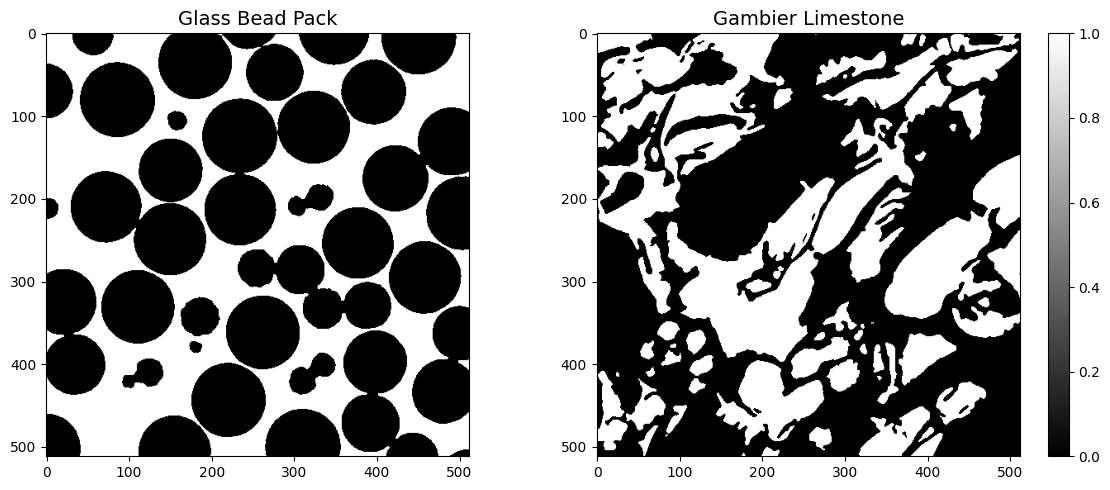

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(12,5))
ax = ax.flatten()

im = ax[0].imshow(beadpack[0,:,:], cmap='gray', interpolation=None)
ax[0].set_title('Glass Bead Pack',fontsize=14)

im2 = ax[1].imshow(gambier[0,:,:], cmap='gray', interpolation=None)
ax[1].set_title('Gambier Limestone',fontsize=14)

plt.colorbar(im2)
plt.tight_layout()
plt.show()

## Initial Visualizations <a class="anchor" id="section_1_4"></a>

In [6]:
subset_range = (128,256)
plot_sample(beadpack, subset=True, subset_range=subset_range)
plot_sample(gambier, subset=True, subset_range=subset_range)

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [18]:
# Porosity of the selected subset of Gambier Limestone
gambier_128 = gambier[128:256, 128:256, 128:256]
porosity = np.sum(gambier_128 == 1)/(128**3)*100
print(round(porosity, 1), '%')

71.6 %


## Finding the Competent Subsets <a class="anchor" id="section_1_4"></a>

In [ ]:
subset1, _ = extract_competent_subset(beadpack, cube_size=128, batch=100, pore_class = 1, class_to_optimize = 1)

Original Porosity: 37.88 %
Subset Porosity: 37.89 %
Competent Subset: [183:311,            183:311, 183:311]


In [ ]:
subset2, _ = extract_competent_subset(gambier, cube_size=128, batch=100, pore_class = 1, class_to_optimize = 1, debug=True, exhaustive_search=True)

Original Porosity: 43.59 %
Subset Porosity: 50.36 %
Competent Subset: [224:352,            224:352, 224:352]


## Final Visualizations <a class="anchor" id="section_1_5"></a>

In [ ]:
plot_sample(beadpack, subset=True, subset_range=subset1)
plot_sample(gambier, subset=True, subset_range=subset2)

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## 3D Printing Case

In [ ]:
subset,_ = extract_competent_subset(gambier, cube_size=100, batch=50, 
                                     pore_class=0, class_to_optimize=1, 
                                     for_3d_printing=True,exhaustive_search=True,
                                   max_overhang_angle = 30)
x_range, y_range, z_range = subset
gambier_subset = gambier[x_range[0]:x_range[1], 
                       y_range[0]:y_range[1], 
                       z_range[0]:z_range[1]]


Finding valid subsets:   0%|          | 0/50 [00:00<?]

Overhang surface area: 29.54%
Original Porosity (class 0): 56.4 %
Subset Porosity: 45.12 %
Optimized for class 1 connectivity
Competent Subset: [53:153,40:140, 68:168]


____

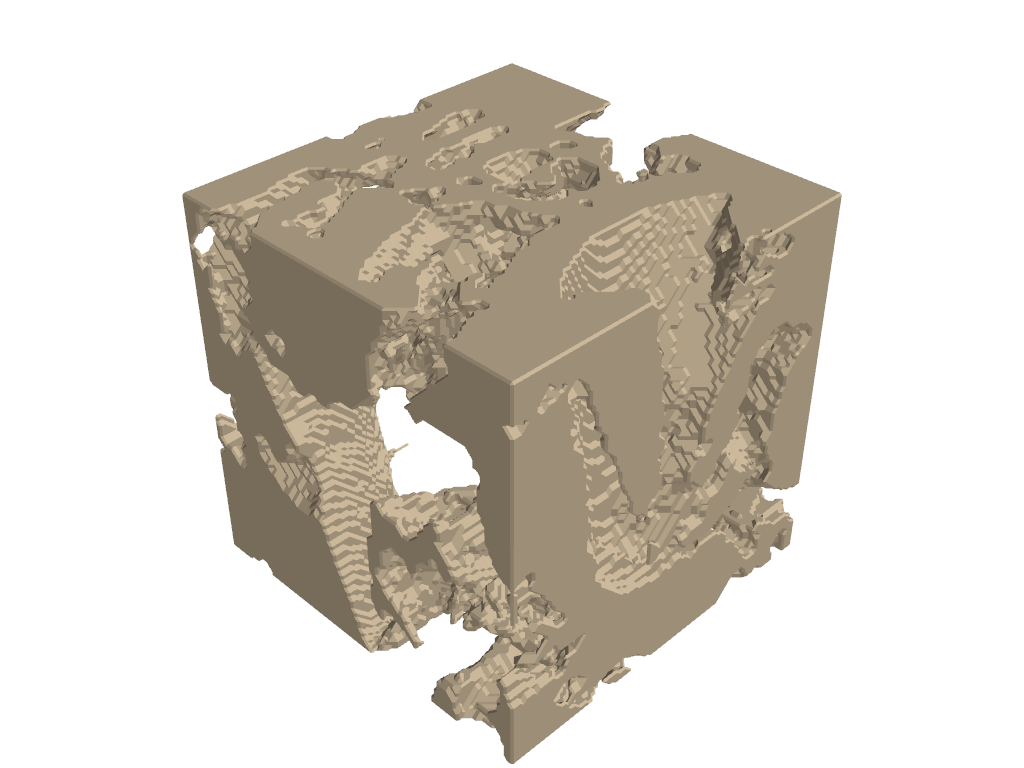

In [ ]:
denoised = cc3d.dust(
  gambier_subset, threshold=5000, 
  connectivity=26, in_place=False
)

plot_sample(denoised)

## Visualizing the Overhangs

We include a helper function here for this.

In [ ]:
def visualize_overhangs(
    sample_subset,
    max_overhang_angle=30,
    simplify=None,              # e.g. 0.7 removes ~70% of faces
    subset=True,
    subset_range=(0, 128),
):
    """
    Detect and visualize overhangs in a 3D binary voxel array.
    Parameters
    ----------
    sample_subset : np.ndarray
        3D binary array (1 = solid, 0 = void)
    max_overhang_angle : float
        Max printable overhang angle (degrees from vertical)
    simplify : float or None
        Fraction of faces to remove (PyVista decimation).
        Example: 0.7 removes ~70% of faces.
    subset : bool
        Whether to crop the volume
    subset_range : tuple
        Cropping range. Can be:
        - Diagonal mode: (min, max) - same range for all dimensions
        - Exhaustive mode: ((x_min, x_max), (y_min, y_max), (z_min, z_max))
    """
    # -----------------------------
    # Crop volume
    # -----------------------------
    if subset:
        # Check if diagonal mode (simple tuple) or exhaustive mode (nested tuples)
        if isinstance(subset_range[0], tuple):
            # Exhaustive mode: ((x_min, x_max), (y_min, y_max), (z_min, z_max))
            x_range, y_range, z_range = subset_range
            volume = sample_subset[x_range[0]:x_range[1], 
                                  y_range[0]:y_range[1], 
                                  z_range[0]:z_range[1]]
        else:
            # Diagonal mode: (min, max)
            mini, maxi = subset_range
            volume = sample_subset[mini:maxi, mini:maxi, mini:maxi]
    else:
        volume = sample_subset.copy()
    
    volume = volume.astype(float)
    # volume = 1 - volume.astype(float)
    volume = np.pad(volume, ((1, 1), (1, 1), (1, 1)), mode='constant', constant_values=1)
    
    # -----------------------------
    # Marching cubes (voxel-true surface)
    # -----------------------------
    verts, faces, _, _ = skimage.measure.marching_cubes(
        volume,
        level=0.5
    )
    
    # Convert faces to PyVista format
    faces_pv = np.hstack(
        [np.full((faces.shape[0], 1), 3), faces]
    )
    pv_mesh = pv.PolyData(verts, faces_pv)
    
    # -----------------------------
    # Simplify mesh (OPTIONAL)
    # -----------------------------
    if simplify is not None:
        if not (0.0 < simplify < 1.0):
            raise ValueError("simplify must be between 0 and 1")
        pv_mesh = pv_mesh.decimate_pro(simplify, preserve_topology=True)
    
    # -----------------------------
    # Recompute normals AFTER simplification
    # -----------------------------
    pv_mesh.compute_normals(
        cell_normals=True,
        point_normals=False,
        inplace=True
    )
    face_normals = pv_mesh.cell_normals
    
    # -----------------------------
    # Overhang detection
    # -----------------------------
    build_dir = np.array([0.0, 0.0, 1.0])
    cos_theta = face_normals @ build_dir
    angles = np.degrees(
        np.arccos(np.clip(cos_theta, -1.0, 1.0))
    )
    
    overhang_faces = angles > (90.0 + max_overhang_angle)
    face_areas = pv_mesh.compute_cell_sizes(
        length=False, area=True, volume=False
    )["Area"]
    
    percent_overhang_area = (
        100.0 * face_areas[overhang_faces].sum() / face_areas.sum()
    )
    print(f"Overhang surface area: {percent_overhang_area:.2f}%")
    
    # -----------------------------
    # Face coloring
    # -----------------------------
    face_colors = np.zeros((pv_mesh.n_faces, 4), dtype=np.uint8)
    face_colors[:] = [200, 181, 152, 255]       # normal surface
    face_colors[overhang_faces] = [220, 50, 50, 255]  # overhangs
    pv_mesh.cell_data["Colors"] = face_colors
    
    # -----------------------------
    # Visualization
    # -----------------------------
    plotter = pv.Plotter(lighting="three lights")
    plotter.set_background("white")
    pv.global_theme.font.color = "black"
    pv.global_theme.font.size = 18
    pv.global_theme.font.label_size = 14
    
    plotter.add_mesh(
        pv_mesh,
        scalars="Colors",
        rgb=True,
        opacity=1.0,
        show_edges=False
    )
    
    plotter.add_text(
        f"Overhangs > {max_overhang_angle}°  |  simplify={simplify}",
        font_size=14
    )
    
    plotter.show()

Overhang surface area: 29.03%


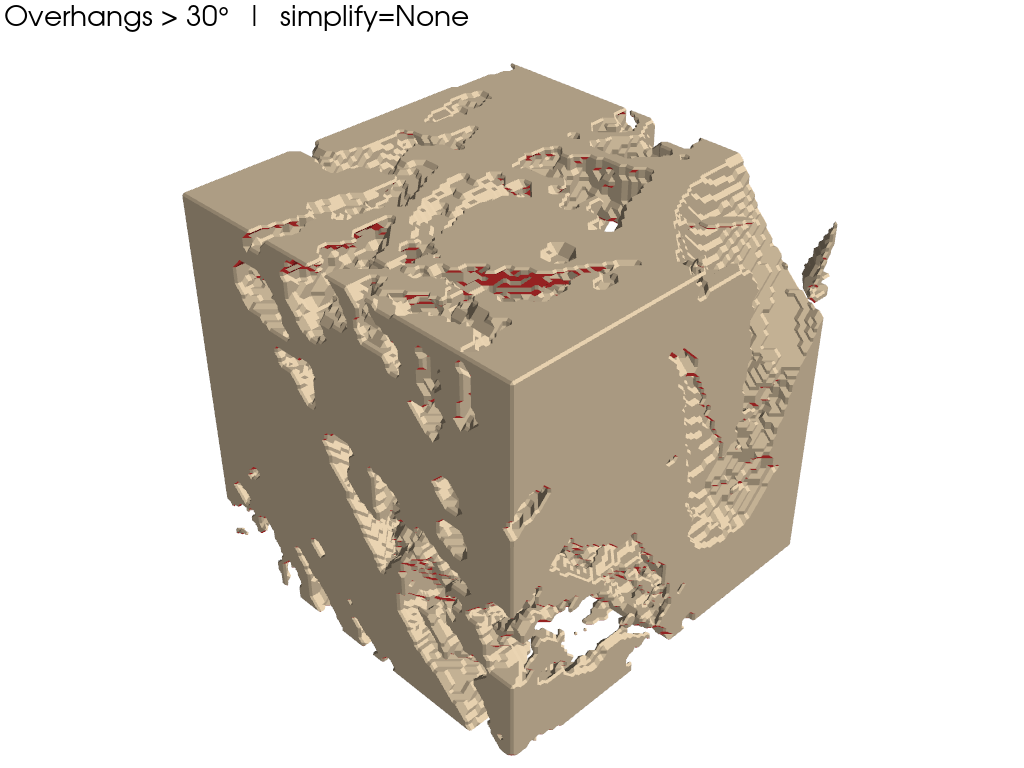

In [ ]:
visualize_overhangs(
    denoised,
    simplify=None,
    max_overhang_angle=30,
    subset=False
)

Author: [Çınar Turhan](https://www.linkedin.com/in/cinarturhan/)